# 08 — The live archive versus the 2020 snapshot

**Question this notebook answers:** what has the NASA Exoplanet Archive changed about these 9,564 KOIs since the snapshot the project was built on, and what do those changes say about our models and our habitable-zone list?

**Inputs:** `data/raw/cumulative_kaggle_snapshot.csv` (the 2020 project's data) and `data/raw/cumulative_tap_2026-08-25.csv` (pulled from the archive's TAP service with `python -m kepler.fetch`; provenance JSON alongside). **Outputs:** tables in `reports/tables/08_*.csv`, figures in `reports/figures/live/`.

> **Why this matters.** The physics columns are **identical** in the two tables; only the *verdicts* moved. That makes the live table a genuine out-of-time test: a model that only ever saw 2017-era physics and labels can be scored against what the community decided years later.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score

from kepler import data, habitable, preprocess, viz
from kepler.data import CLASSES, TARGET, label, tap_pulls
from kepler.models import add_missing_indicators, hgb_model, score
from kepler.paths import FIGURES, REPORTS

viz.apply_style()
FIG_DIR = FIGURES / "live"; FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = REPORTS / "tables"; TABLE_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 180); pd.set_option("display.precision", 3)

## 1. Load both tables and check they describe the same objects

In [2]:
snap = data.load_kaggle_snapshot()
live_path = tap_pulls()[-1]
live = data.load_tap_pull(live_path)
prov = json.loads(live_path.with_suffix(".provenance.json").read_text())
print("live pull:", live_path.name, "| pulled", prov["pulled_at_utc"], "| sha256", prov["sha256"][:12], "| shape", live.shape)
print("same KOIs:", set(snap.index) == set(live.index), "| snapshot columns absent from live:", sorted(set(snap.columns) - set(live.columns)))
both = snap.join(live, rsuffix="_live", how="inner")
phys = ["koi_period", "koi_impact", "koi_duration", "koi_prad", "koi_teq", "koi_insol", "koi_model_snr", "koi_steff", "koi_slogg", "koi_srad", "koi_kepmag", "koi_depth"]
changed = {c: int(((both[c] != both[c + "_live"]) & ~(both[c].isna() & both[c + "_live"].isna())).sum()) for c in phys}
print("physics columns with changed values:", {k: v for k, v in changed.items() if v})
d = both[["koi_depth", "koi_depth_live"]].dropna(); d = d[d.koi_depth != d.koi_depth_live]
print(f"koi_depth differences are rounding only: median relative change {((d.koi_depth_live - d.koi_depth) / d.koi_depth).abs().median():.1e}")

live pull: cumulative_tap_2026-08-25.csv | pulled 2026-08-25T18:30:33+00:00 | sha256 37fffa141e05 | shape (9564, 152)
same KOIs: True | snapshot columns absent from live: ['rowid']
physics columns with changed values: {'koi_depth': 997}
koi_depth differences are rounding only: median relative change 9.5e-06


## 2. What moved: the verdicts

Rows are the snapshot disposition, columns today's. The diagonal is "unchanged".

koi_disposition_live,CANDIDATE,CONFIRMED,FALSE POSITIVE,total
koi_disposition,,,,
CANDIDATE,1657,443,148,2248
CONFIRMED,0,2292,1,2293
FALSE POSITIVE,320,13,4690,5023


925 of 9,564 KOIs (9.7%) changed archive disposition


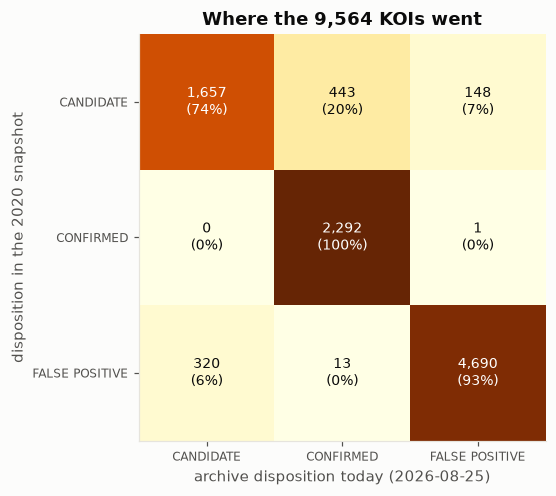

In [3]:
trans = pd.crosstab(both[TARGET], both[TARGET + "_live"]).reindex(index=CLASSES, columns=CLASSES)
trans_pct = (trans.T / trans.sum(axis=1)).T
display(trans.assign(total=trans.sum(axis=1)))
moved = int(trans.to_numpy().sum() - np.trace(trans.to_numpy()))
print(f"{moved:,} of {len(both):,} KOIs ({moved / len(both):.1%}) changed archive disposition")

fig, ax = viz.new_figure(6.5, 4.8)
im = ax.imshow(trans_pct.to_numpy(), cmap=viz.SEQUENTIAL_CMAP, vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        v = trans.iloc[i, j]
        ax.text(j, i, f"{v:,}\n({trans_pct.iloc[i, j]:.0%})", ha="center", va="center", fontsize=9,
                color="white" if trans_pct.iloc[i, j] > 0.6 else viz.TEXT_PRIMARY)
ax.set_xticks(range(3)); ax.set_yticks(range(3)); ax.set_xticklabels(CLASSES, fontsize=8); ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel("archive disposition today (2026-08-25)"); ax.set_ylabel("disposition in the 2020 snapshot"); ax.grid(False)
ax.set_title("Where the 9,564 KOIs went")
fig.savefig(FIG_DIR / "disposition_transitions.png"); plt.show()

### The vetting moved with the labels

The four false-positive flags and the pipeline verdict were *also* updated for hundreds of rows, and the 320 KOIs that went from FALSE POSITIVE back to CANDIDATE are exactly rows whose flags were cleared. So the flags are not a fixed physical measurement; they are part of the verdict and travel with it. One more reason the physics-only model is the one to trust out of time.

In [4]:
flags = preprocess.FLAG_COLUMNS
flag_changes = {f: int((both[f] != both[f + "_live"]).sum()) for f in flags}
flag_changes["koi_pdisposition"] = int((both["koi_pdisposition"] != both["koi_pdisposition_live"]).sum())
print("rows whose vetting changed:", flag_changes)
fp_to_cand = both[(both[TARGET] == "FALSE POSITIVE") & (both[TARGET + "_live"] == "CANDIDATE")]
print(f"FALSE POSITIVE -> CANDIDATE ({len(fp_to_cand)}): flagged in the snapshot {int((fp_to_cand[flags].max(axis=1) > 0).sum())}, flagged today {int((fp_to_cand[[f + '_live' for f in flags]].max(axis=1) > 0).sum())}; "
      f"by delivery {fp_to_cand['koi_tce_delivname'].value_counts(dropna=False).to_dict()}")

rows whose vetting changed: {'koi_fpflag_nt': 347, 'koi_fpflag_ss': 207, 'koi_fpflag_co': 133, 'koi_fpflag_ec': 2, 'koi_pdisposition': 527}
FALSE POSITIVE -> CANDIDATE (320): flagged in the snapshot 320, flagged today 1; by delivery {'q1_q16_tce': 169, 'q1_q17_dr25_tce': 148, 'q1_q17_dr24_tce': 3}


### Named movers

Thirteen 2020-era false positives are confirmed planets today, including **Kepler-1649 c** (K03138.02), the Earth-sized habitable-zone planet flagged in notebook 05. One confirmed planet went the other way: **Kepler-503 b** is now listed as a false positive.

In [5]:
movers = both[both[TARGET] != both[TARGET + "_live"]].copy()
movers["change"] = movers[TARGET] + " → " + movers[TARGET + "_live"]
named = movers[movers["kepler_name_live"].notna()][["kepler_name_live", "change", "koi_period", "koi_prad", "koi_insol", "koi_steff", "koi_pdisposition_live"]]
named = named.rename(columns={"kepler_name_live": "kepler_name", "koi_pdisposition_live": "pipeline verdict today"})
display(named[named["change"].str.startswith("FALSE POSITIVE →") | named["change"].str.startswith("CONFIRMED →")].sort_values("change"))
print("CANDIDATE → CONFIRMED planets now named:", int((movers["change"] == "CANDIDATE → CONFIRMED").sum()), "(e.g.", ", ".join(named[named["change"] == "CANDIDATE → CONFIRMED"]["kepler_name"].head(5)), "...)")

,kepler_name,change,koi_period,koi_prad,koi_insol,koi_steff,pipeline verdict today
kepoi_name,,,,,,,
K00242.01,Kepler-503 b,CONFIRMED → FALSE POSITIVE,7.258,5.53,141.30,5638.0,CANDIDATE
K03138.02,Kepler-1649 c,FALSE POSITIVE → CONFIRMED,19.535,0.53,0.16,2703.0,FALSE POSITIVE
K00102.02,Kepler-1990 c,FALSE POSITIVE → CONFIRMED,4.068,0.98,442.08,5751.0,CANDIDATE
K04625.01,Kepler-1964 b,FALSE POSITIVE → CONFIRMED,2.441,21.29,223.80,4803.0,CANDIDATE
K03440.01,Kepler-1980 b,FALSE POSITIVE → CONFIRMED,33.026,2.21,23.95,5819.0,CANDIDATE
K01681.02,Kepler-1984 b,FALSE POSITIVE → CONFIRMED,1.993,6.81,48.82,3638.0,CANDIDATE
K02061.01,Kepler-2001 c,FALSE POSITIVE → CONFIRMED,14.093,1.82,30.10,5081.0,CANDIDATE
K06103.01,Kepler-1981 b,FALSE POSITIVE → CONFIRMED,453.542,9.23,5.45,5874.0,CANDIDATE
K03184.02,Kepler-1972 c,FALSE POSITIVE → CONFIRMED,11.322,0.91,515.77,6003.0,FALSE POSITIVE


CANDIDATE → CONFIRMED planets now named: 443 (e.g. Kepler-1976 b, Kepler-1727 b, Kepler-1728 b, Kepler-27 d, Kepler-1729 b ...)


## 3. An out-of-time test of the physics-only model

Train the notebook-07 physics-only model with **2020 labels only**, out-of-fold (5 folds, fixed parameters), and look at what it thought of the KOIs whose verdict later changed. If physics carries real signal, the snapshot-era CANDIDATEs that were later **confirmed** should have looked more planet-like to it than those later dismissed as **false positives**.

,n,median P(planet-like),mean
later CONFIRMED,443.0,0.946,0.901
still CANDIDATE,1657.0,0.826,0.711
later FALSE POSITIVE,148.0,0.257,0.354


Among 2020 CANDIDATEs later decided (591), AUC of the 2020 physics-only P(planet-like) for CONFIRMED vs FALSE POSITIVE: 0.937


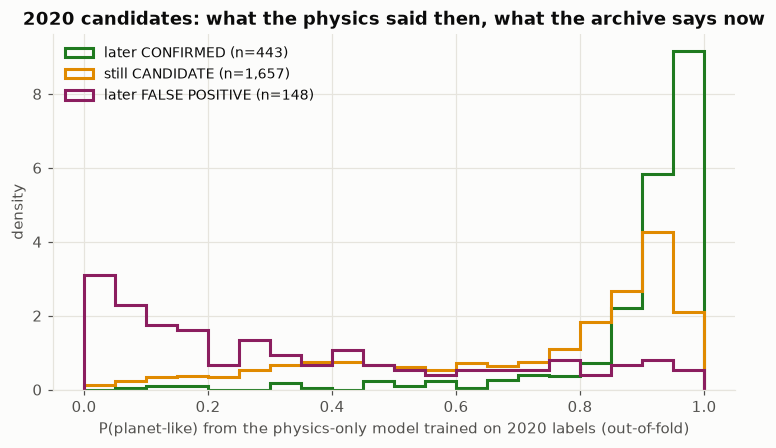

In [6]:
clean_snap = preprocess.clean(snap)
t = preprocess.model_table(clean_snap, "physics_only", dropna=False)
X = add_missing_indicators(t.X); y_snap = t.y
contract = json.loads((REPORTS.parent / "models" / "hgb_physics_only_calibrated.contract.json").read_text()) if (REPORTS.parent / "models" / "hgb_physics_only_calibrated.contract.json").exists() else None
best = contract["params"] if contract else {"learning_rate": 0.05, "max_leaf_nodes": 31, "min_samples_leaf": 20}
folds = StratifiedKFold(5, shuffle=True, random_state=0)
proba = cross_val_predict(hgb_model(**best), X, y_snap, cv=folds, method="predict_proba")
p_planet = proba[:, 0] + proba[:, 1]  # CANDIDATE + CONFIRMED = "looks like a planet"
both["p_planet_2020"] = pd.Series(p_planet, index=X.index)

was_cand = both[both[TARGET] == "CANDIDATE"]
later = was_cand[TARGET + "_live"]
groups = {"later CONFIRMED": was_cand[later == "CONFIRMED"], "still CANDIDATE": was_cand[later == "CANDIDATE"], "later FALSE POSITIVE": was_cand[later == "FALSE POSITIVE"]}
summary = pd.DataFrame({k: {"n": len(g), "median P(planet-like)": g["p_planet_2020"].median(), "mean": g["p_planet_2020"].mean()} for k, g in groups.items()}).T
display(summary.round(3))
decided = was_cand[later != "CANDIDATE"]
auc = roc_auc_score((decided[TARGET + "_live"] == "CONFIRMED").astype(int), decided["p_planet_2020"])
print(f"Among 2020 CANDIDATEs later decided ({len(decided)}), AUC of the 2020 physics-only P(planet-like) for CONFIRMED vs FALSE POSITIVE: {auc:.3f}")

fig, ax = viz.new_figure(8, 4.2)
bins = np.linspace(0, 1, 21)
colors = {"later CONFIRMED": viz.CLASS_COLORS["CONFIRMED"], "still CANDIDATE": viz.CLASS_COLORS["CANDIDATE"], "later FALSE POSITIVE": viz.CLASS_COLORS["FALSE POSITIVE"]}
for k, g in groups.items():
    ax.hist(g["p_planet_2020"], bins=bins, density=True, histtype="step", lw=2, color=colors[k], label=f"{k} (n={len(g):,})")
ax.set_xlabel("P(planet-like) from the physics-only model trained on 2020 labels (out-of-fold)")
ax.set_ylabel("density"); ax.set_title("2020 candidates: what the physics said then, what the archive says now")
ax.legend(loc="upper left")
fig.savefig(FIG_DIR / "out_of_time_candidates.png"); plt.show()

> **Reading it.** The model never saw today's labels, yet the candidates it rated most planet-like in 2020 physics are disproportionately the ones the archive has since confirmed, and the ones it doubted are disproportionately the ones now dismissed. That is the physics-only signal surviving an out-of-time test that the flags could never pass (they were rewritten along with the verdicts).

## 4. Retrain on today's labels

Same features, same parameters, 5-fold CV with the live dispositions as the target.

In [7]:
y_live = live.loc[X.index, TARGET].map(data.CLASS_CODES).astype("int64")
cv_live = cross_val_score(hgb_model(**best), X, y_live, cv=folds, scoring="f1_macro")
cv_snap = cross_val_score(hgb_model(**best), X, y_snap, cv=folds, scoring="f1_macro")
pd.DataFrame({"labels": ["2020 snapshot", "live 2026-08-25"], "macro f1 (5-fold CV, physics-only)": [f"{cv_snap.mean():.3f} ± {cv_snap.std():.3f}", f"{cv_live.mean():.3f} ± {cv_live.std():.3f}"],
              "class counts": [y_snap.value_counts().sort_index().tolist(), y_live.value_counts().sort_index().tolist()]})

,labels,"macro f1 (5-fold CV, physics-only)",class counts
0,2020 snapshot,0.723 ± 0.007,"[2248, 2293, 5023]"
1,live 2026-08-25,0.747 ± 0.012,"[1977, 2748, 4839]"


## 5. The habitable-zone list on today's table

Same screen as notebook 05 (Kopparapu 2014 limits, radius ≤ 2 R⊕, conservative zone), now with today's dispositions. The physics is unchanged, so the only thing that can move a planet on or off the list is its verdict.

In [8]:
hz_live = habitable.hz_table(live)
hz_snap = habitable.hz_table(snap)
display(habitable.summarise(hz_live, "CONFIRMED").style.set_caption("CONFIRMED today, inside each zone"))
now = hz_live[(hz_live[TARGET] == "CONFIRMED") & hz_live["hz_conservative"] & hz_live["super_earth"]]
then = hz_snap[(hz_snap[TARGET] == "CONFIRMED") & hz_snap["hz_conservative"] & hz_snap["super_earth"]]
entered = now.index.difference(then.index); left = then.index.difference(now.index)
print(f"confirmed, conservative zone, ≤ 2 R⊕: {len(then)} in the snapshot → {len(now)} today | entered: {list(now.loc[entered, 'kepler_name'])} | left: {list(then.loc[left, 'kepler_name'])}")
display(now.loc[entered, ["kepler_name", "koi_period", "koi_prad", "koi_insol", "koi_steff", "sunlike_host", "rocky"]].sort_values("koi_insol"))
k1649c = hz_live.loc["K03138.02", ["kepler_name", TARGET, "koi_prad", "koi_insol", "koi_steff", "seff_maximum_greenhouse", "hz_conservative", "hz_optimistic"]]
print("\nKepler-1649 c with the catalogue's own numbers:"); print(k1649c.to_string())

,any radius,radius <= 2.0,radius <= 1.6,"radius <= 2.0, Sun-like host","radius <= 2.0, cooler host"
hz_conservative,34,16,9,1,15
hz_optimistic,67,25,12,2,23


confirmed, conservative zone, ≤ 2 R⊕: 15 in the snapshot → 16 today | entered: ['Kepler-1652 b'] | left: []


,kepler_name,koi_period,koi_prad,koi_insol,koi_steff,sunlike_host,rocky
kepoi_name,,,,,,,
K02626.01,Kepler-1652 b,38.097,1.58,0.81,3554.0,False,True



Kepler-1649 c with the catalogue's own numbers:
kepler_name                Kepler-1649 c
koi_disposition                CONFIRMED
koi_prad                            0.53
koi_insol                           0.16
koi_steff                         2703.0
seff_maximum_greenhouse            0.225
hz_conservative                    False
hz_optimistic                      False


> **Kepler-1649 c** is confirmed today, but with the KOI table's own DR25 parameters (insolation 0.16 Earth flux at a 2,703 K star, where the conservative outer edge is about 0.22) it sits just outside the zone. The discovery paper revised the stellar parameters; the cumulative KOI table does not carry those revisions. This is the table's limitation, not the planet's, and it argues for pulling the archive's *planetary systems* table for the confirmed planets in a later phase.

## 6. Save

In [9]:
trans.to_csv(TABLE_DIR / "08_disposition_transitions.csv")
movers["p_planet_2020"] = both.loc[movers.index, "p_planet_2020"]
movers[["kepler_name_live", "change", "koi_period", "koi_prad", "koi_insol", "koi_steff", "koi_tce_delivname", "p_planet_2020"]].rename(columns={"kepler_name_live": "kepler_name"}).to_csv(TABLE_DIR / "08_movers.csv")
now[["kepler_name", "koi_period", "koi_prad", "koi_insol", "koi_insol_err1", "koi_insol_err2", "koi_steff", "sunlike_host", "rocky", "hz_conservative_possible", "koi_pdisposition"]].to_csv(TABLE_DIR / "08_hz_confirmed_live.csv")
print("wrote reports/tables/08_disposition_transitions.csv, 08_movers.csv", movers.shape, ", 08_hz_confirmed_live.csv", now.shape)

wrote reports/tables/08_disposition_transitions.csv, 08_movers.csv (925, 203) , 08_hz_confirmed_live.csv (16, 164)


## Summary

- Same 9,564 KOIs, identical physics, **925 changed verdicts** since the snapshot: 443 candidates confirmed, 148 candidates dismissed, 320 false positives reinstated as candidates (their flags were cleared), 13 false positives now confirmed planets (Kepler-1649 c among them), 1 confirmed planet retracted (Kepler-503 b).
- The vetting flags were rewritten along with the verdicts, which settles the leakage argument for good: they are outputs, not inputs.
- The physics-only model, trained on 2020 labels, ranks the later-confirmed candidates above the later-dismissed ones (AUC in the cell above): real, if modest, physical signal.
- Retraining on today's labels gives a physics-only macro f1 in the same ≈ 0.72 band (see §4).
- The confirmed small-planet habitable-zone list grew from 15 to the count in §5, purely from new confirmations. Kepler-1649 c needs the systems table's revised parameters to appear; a job for Phase 5 or later.